# Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a tabular dataset you provide.

It includes:
- Missing values analysis and visualization
- Zeros analysis
- Automatic plotting for numerical and categorical variables
- Target variable analysis
- Handling missing values and zeros with a chosen strategy
- Outlier detection and treatment (IQR and Z-score)
- Variance analysis and optional feature removal

At the end, it reports a concise summary of the cleaning actions and the final dataset info, and saves the cleaned dataset into the in-memory variable `df_cleaned` for further work.


In [1]:
# Setup: imports, configuration, and helper utilities
from __future__ import annotations
import os
import sys
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot style
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Auto-detect dataset path in project structure; fallback to prompt
DEFAULT_DATA_PATHS = [
    os.path.join("Data", "video_game_reviews.csv"),  # project default
    os.path.join("..", "Data", "video_game_reviews.csv"),  # parent when running from EDA/
    os.path.join("data", "video_game_reviews.csv"),  # common variant
]

# Helper: safe load CSV with basic dtype inference

def load_dataset(possible_paths: List[str] | None = None) -> pd.DataFrame:
    paths = possible_paths if possible_paths is not None else DEFAULT_DATA_PATHS
    for path in paths:
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                print(f"Loaded dataset from: {path} | shape={df.shape}")
                return df
            except Exception as e:
                print(f"Failed to read {path}: {e}")
    raise FileNotFoundError(
        "Dataset not found. Please update `DEFAULT_DATA_PATHS` or load your own file in the next cell."
    )

# Helpers: variable type detection

def get_numeric_columns(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def get_categorical_columns(df: pd.DataFrame, exclude: List[str] | None = None) -> List[str]:
    exclude = set(exclude or [])
    cats = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    # Also treat low-cardinality numerics as categorical (heuristic)
    for col in get_numeric_columns(df):
        if col in exclude:
            continue
        unique_count = df[col].nunique(dropna=True)
        if 2 <= unique_count <= max(20, int(0.02 * len(df))):
            cats.append(col)
    # De-duplicate while preserving order
    seen = set()
    ordered = []
    for c in cats:
        if c not in seen:
            seen.add(c)
            ordered.append(c)
    return ordered

# Helpers: plotting

def plot_histogram(df: pd.DataFrame, col: str, bins: int = 30) -> None:
    data = df[col].dropna()
    ax = sns.histplot(data, bins=bins, kde=True, color="#4C78A8")
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.show()


def plot_bar_counts(df: pd.DataFrame, col: str, top_n: int = 20) -> None:
    counts = df[col].astype("object").value_counts(dropna=False).head(top_n)
    ax = sns.barplot(x=counts.values, y=counts.index, color="#72B7B2")
    ax.set_title(f"Top {top_n} Categories in {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)
    plt.show()


def plot_missing_heatmap(df: pd.DataFrame) -> None:
    if df.shape[1] > 0:
        sns.heatmap(df.isna(), cbar=False)
        plt.title("Missing Values Heatmap")
        plt.xlabel("Columns")
        plt.ylabel("Rows")
        plt.show()


def compute_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    num_missing = df.isna().sum()
    pct_missing = (num_missing / len(df)) * 100
    summary = (
        pd.DataFrame({"missing_count": num_missing, "missing_pct": pct_missing})
        .sort_values("missing_pct", ascending=False)
    )
    return summary


def compute_zero_summary(df: pd.DataFrame) -> pd.DataFrame:
    zero_counts = {}
    for col in df.columns:
        series = df[col]
        if pd.api.types.is_numeric_dtype(series):
            zero_counts[col] = int((series == 0).sum())
        else:
            # Non-numeric: treat string "0" as zero if present
            zero_counts[col] = int((series.astype(str) == "0").sum())
    summary = pd.DataFrame({
        "zero_count": pd.Series(zero_counts),
    })
    summary["zero_pct"] = (summary["zero_count"] / len(df)) * 100
    summary = summary.sort_values("zero_pct", ascending=False)
    return summary


def iqr_outlier_bounds(series: pd.Series) -> Tuple[float, float]:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper


def zscore(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    mu = s.mean()
    sigma = s.std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(np.zeros_like(s), index=series.index)
    return (s - mu) / sigma

print("Helpers ready.")


Helpers ready.


## Data Loading

Update the path below if your dataset is located elsewhere. By default, the notebook attempts to load `Data/video_game_reviews.csv`.


In [2]:
# Load the dataset; if not found, provide a manual path
try:
    df = load_dataset()
except FileNotFoundError as e:
    print(str(e))
    # Manual path example: uncomment and set your path
    df = pd.read_csv(r"Data/video_game_reviews.csv")
    raise

print("\nBasic dataset info:")
print(df.shape)
print(df.dtypes)
df.head()


Loaded dataset from: ..\Data\video_game_reviews.csv | shape=(47774, 18)

Basic dataset info:
(47774, 18)
Game Title                  object
User Rating                float64
Age Group Targeted          object
Price                      float64
Platform                    object
Requires Special Device     object
Developer                   object
Publisher                   object
Release Year                 int64
Genre                       object
Multiplayer                 object
Game Length (Hours)        float64
Graphics Quality            object
Soundtrack Quality          object
Story Quality               object
User Review Text            object
Game Mode                   object
Min Number of Players        int64
dtype: object


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


## 1️⃣ Missing Values Analysis

We quantify missingness per column, visualize the pattern, and highlight variables with high missing rates.


In [3]:
# Compute missing values summary
missing_summary = compute_missing_summary(df)
missing_summary


,missing_count,missing_pct
Game Title,0,0.0
User Rating,0,0.0
Age Group Targeted,0,0.0
Price,0,0.0
Platform,0,0.0
Requires Special Device,0,0.0
Developer,0,0.0
Publisher,0,0.0
Release Year,0,0.0
Genre,0,0.0


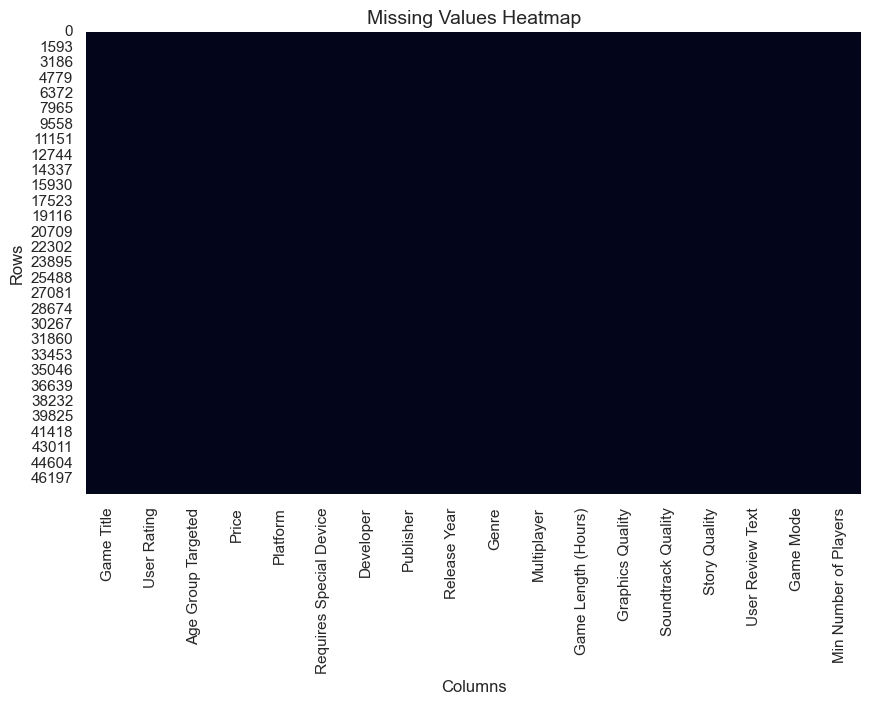

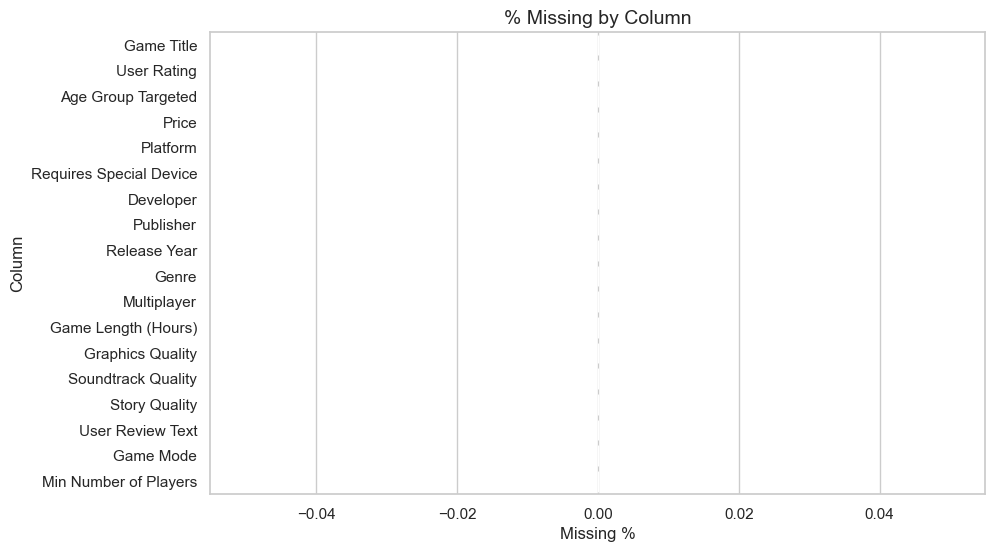

In [4]:
# Visualize missingness: heatmap and bar plot
plot_missing_heatmap(df)

ax = sns.barplot(
    data=missing_summary.reset_index().rename(columns={"index": "column"}),
    x="missing_pct", y="column", color="#F58518"
)
ax.set_title("% Missing by Column")
ax.set_xlabel("Missing %")
ax.set_ylabel("Column")
plt.show()


### Missingness Summary

Columns with high missing percentages may require imputation or dropping, depending on importance and availability of alternatives. We generally flag variables with >30% missing as high-risk for bias or instability if imputed without care.


## 2️⃣ Zeros Analysis

We quantify zeros per column and discuss whether zeros likely represent valid values or placeholders for missing data.


In [5]:
# Compute zero counts and percentages
zero_summary = compute_zero_summary(df)
zero_summary


,zero_count,zero_pct
Game Title,0,0.0
User Rating,0,0.0
Age Group Targeted,0,0.0
Price,0,0.0
Platform,0,0.0
Requires Special Device,0,0.0
Developer,0,0.0
Publisher,0,0.0
Release Year,0,0.0
Genre,0,0.0


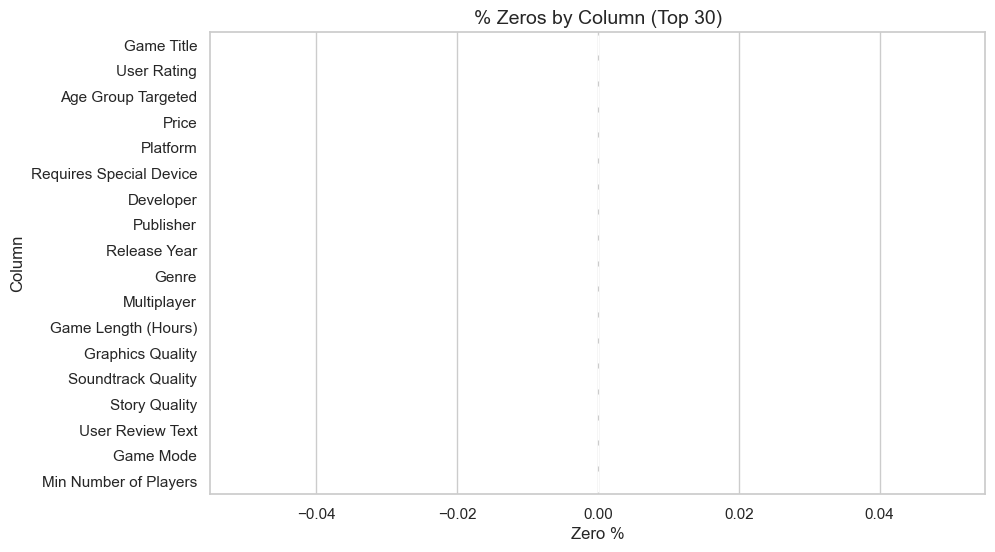

Columns with high zero rates: []


In [6]:
# Visualize zero proportions for top columns
ax = sns.barplot(
    data=zero_summary.reset_index().rename(columns={"index": "column"}).head(30),
    x="zero_pct", y="column", color="#54A24B"
)
ax.set_title("% Zeros by Column (Top 30)")
ax.set_xlabel("Zero %")
ax.set_ylabel("Column")
plt.show()

# Heuristic: flag columns with unusually high zero rate (e.g., >40%)
high_zero_cols = zero_summary[zero_summary["zero_pct"] > 40].index.tolist()
print("Columns with high zero rates:", high_zero_cols)


### Zeros Summary

Zero-heavy columns may encode absence (valid) or missed measurement (invalid). Domain knowledge is key. For example, a zero price could be a promotion (valid) or missing data coded as 0 (invalid). We'll revisit treatment choices later.


## 3️⃣ Plot Each Variable

We automatically detect numerical and categorical variables and plot them accordingly.


In [7]:
numeric_cols = get_numeric_columns(df)
categorical_cols = get_categorical_columns(df)

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)



Numeric columns (5): ['User Rating', 'Price', 'Release Year', 'Game Length (Hours)', 'Min Number of Players']
Categorical columns (17): ['Game Title', 'Age Group Targeted', 'Platform', 'Requires Special Device', 'Developer', 'Publisher', 'Genre', 'Multiplayer', 'Graphics Quality', 'Soundtrack Quality', 'Story Quality', 'User Review Text', 'Game Mode', 'User Rating', 'Release Year', 'Game Length (Hours)', 'Min Number of Players']


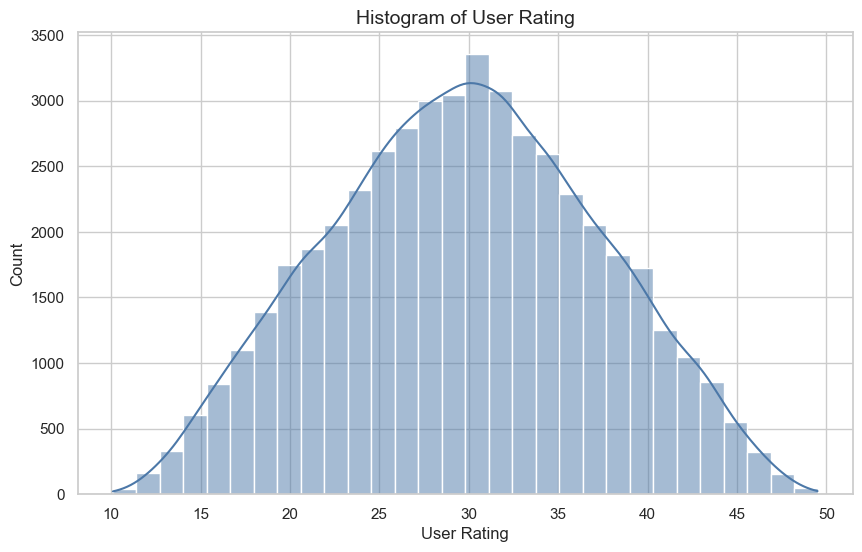

Summary stats for User Rating:
count    47774.000000
mean        29.719329
std          7.550131
min         10.100000
1%          13.900000
5%          17.200000
50%         29.700000
95%         42.300000
99%         45.700000
max         49.500000
Name: User Rating, dtype: float64



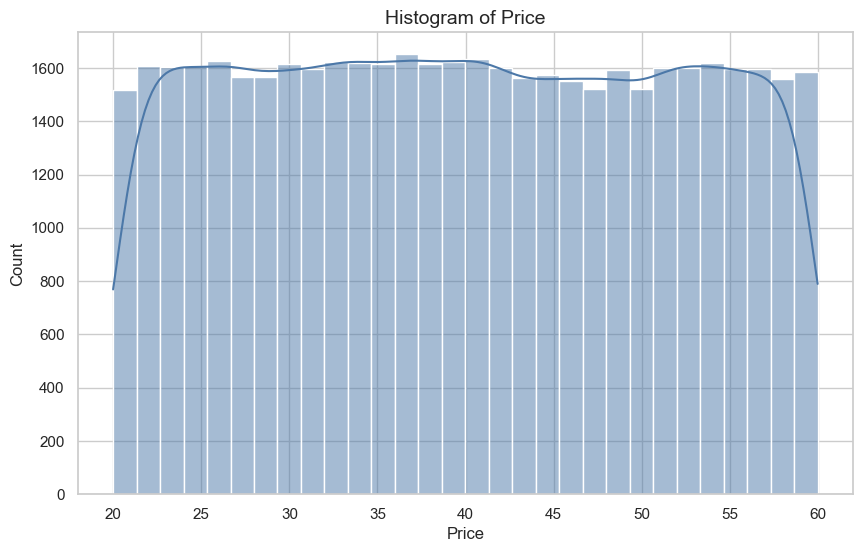

Summary stats for Price:
count    47774.000000
mean        39.951371
std         11.520342
min         19.990000
1%          20.410000
5%          22.050000
50%         39.845000
95%         57.970000
99%         59.590000
max         59.990000
Name: Price, dtype: float64



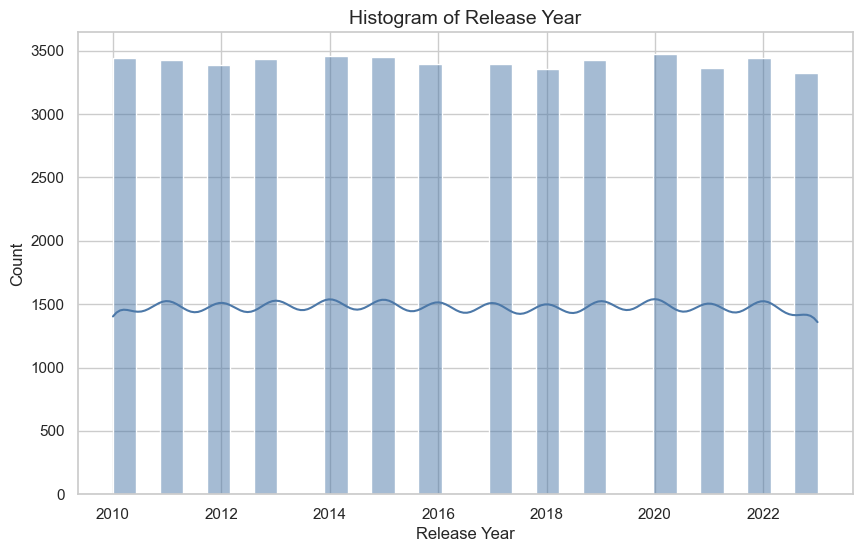

Summary stats for Release Year:
count    47774.000000
mean      2016.480952
std          4.027276
min       2010.000000
1%        2010.000000
5%        2010.000000
50%       2016.000000
95%       2023.000000
99%       2023.000000
max       2023.000000
Name: Release Year, dtype: float64



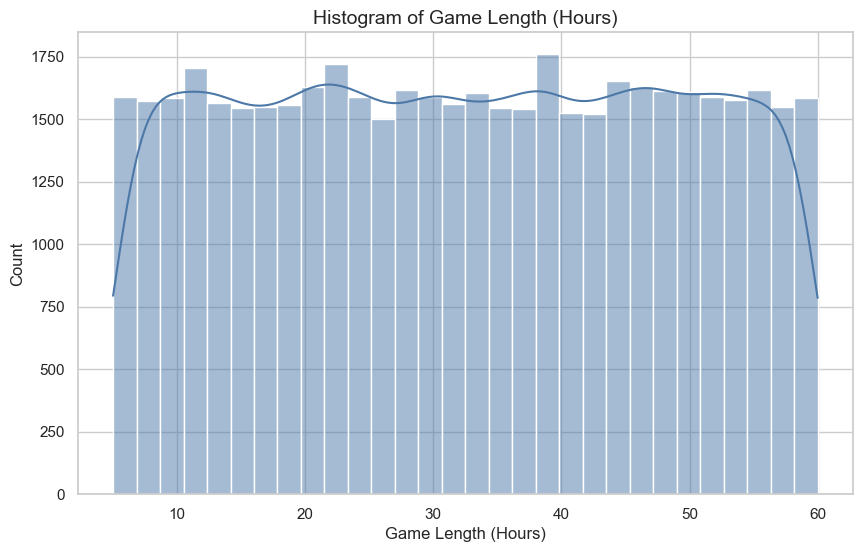

Summary stats for Game Length (Hours):
count    47774.000000
mean        32.481672
std         15.872508
min          5.000000
1%           5.500000
5%           7.800000
50%         32.500000
95%         57.200000
99%         59.400000
max         60.000000
Name: Game Length (Hours), dtype: float64



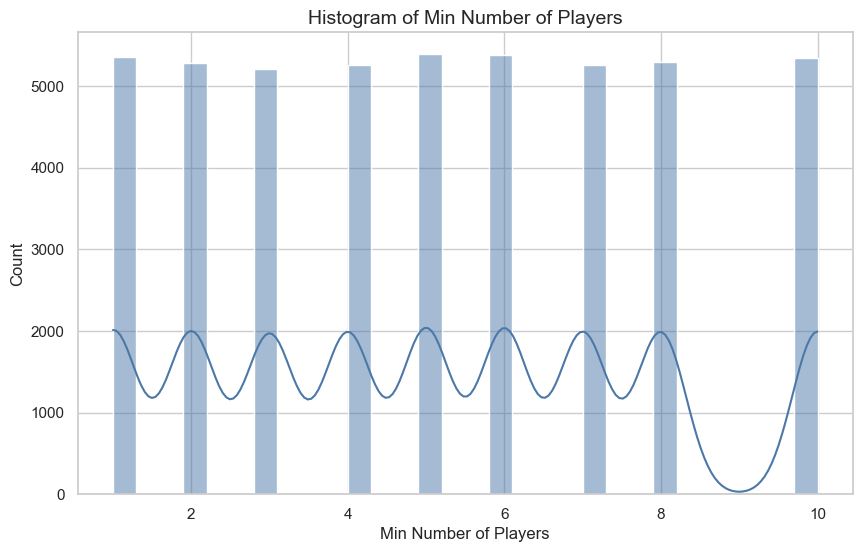

Summary stats for Min Number of Players:
count    47774.000000
mean         5.116758
std          2.769521
min          1.000000
1%           1.000000
5%           1.000000
50%          5.000000
95%         10.000000
99%         10.000000
max         10.000000
Name: Min Number of Players, dtype: float64



In [8]:
# Plot distributions for numerical variables
for col in numeric_cols:
    plot_histogram(df, col)
    desc = df[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
    print(f"Summary stats for {col}:\n{desc}\n")


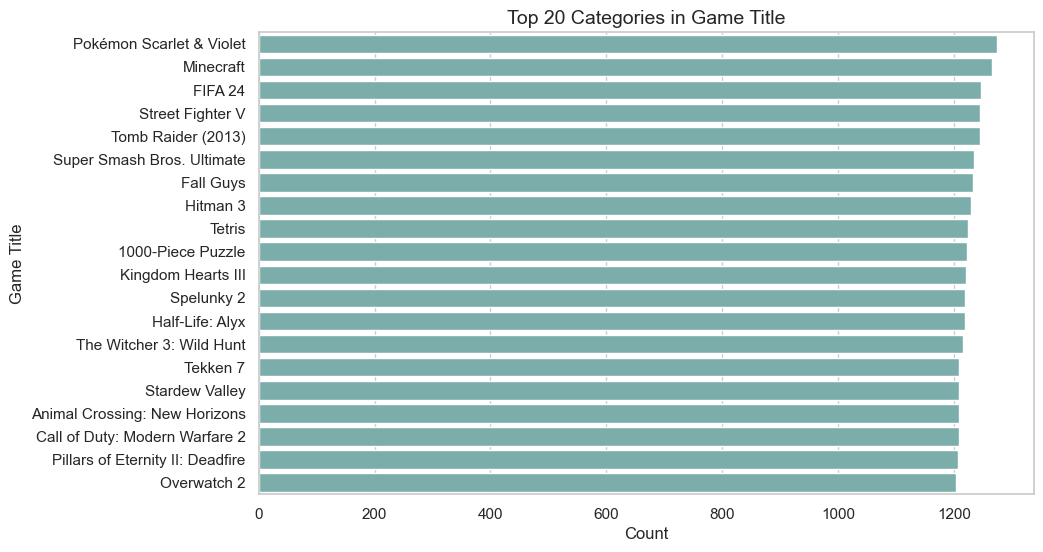

Top categories for Game Title:
Game Title
Pokémon Scarlet & Violet      1274
Minecraft                     1265
FIFA 24                       1247
Street Fighter V              1245
Tomb Raider (2013)            1245
Super Smash Bros. Ultimate    1235
Fall Guys                     1232
Hitman 3                      1229
Tetris                        1224
1000-Piece Puzzle             1222
Name: count, dtype: int64



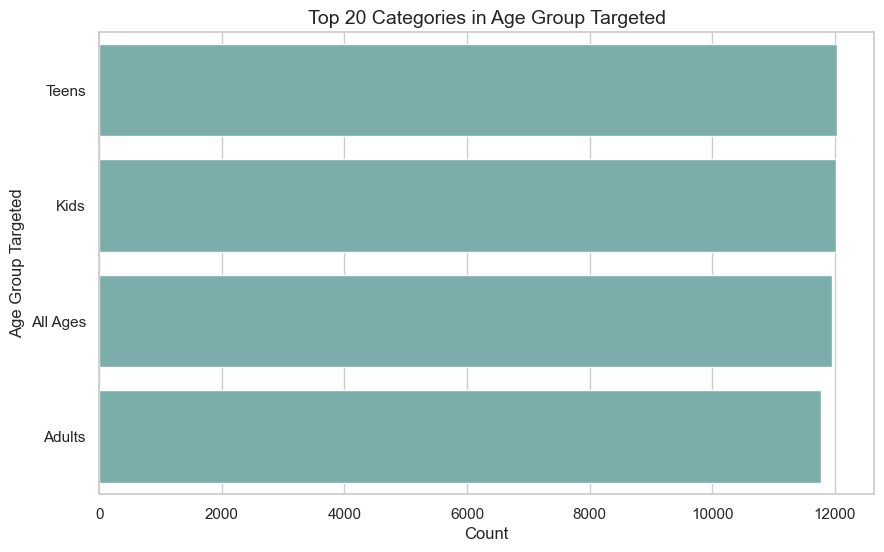

Top categories for Age Group Targeted:
Age Group Targeted
Teens       12038
Kids        12013
All Ages    11954
Adults      11769
Name: count, dtype: int64



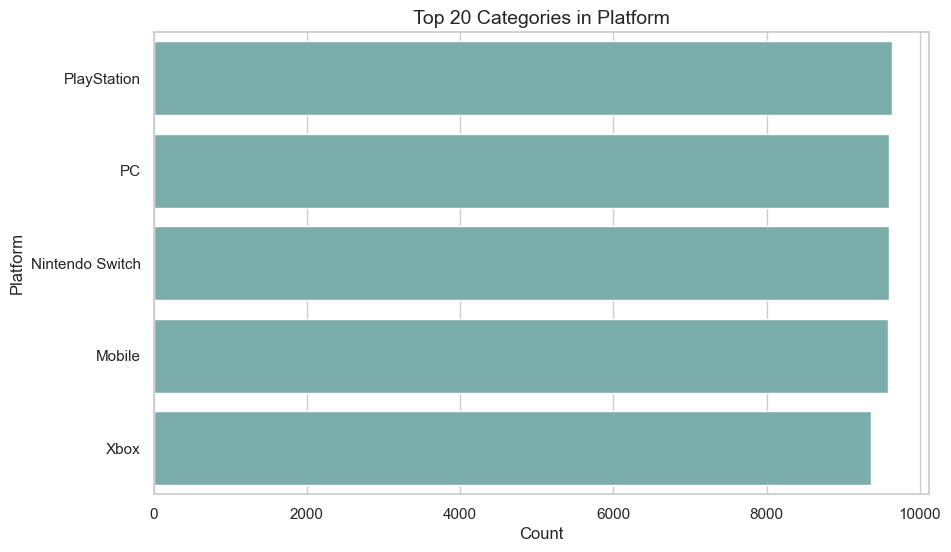

Top categories for Platform:
Platform
PlayStation        9633
PC                 9599
Nintendo Switch    9596
Mobile             9589
Xbox               9357
Name: count, dtype: int64



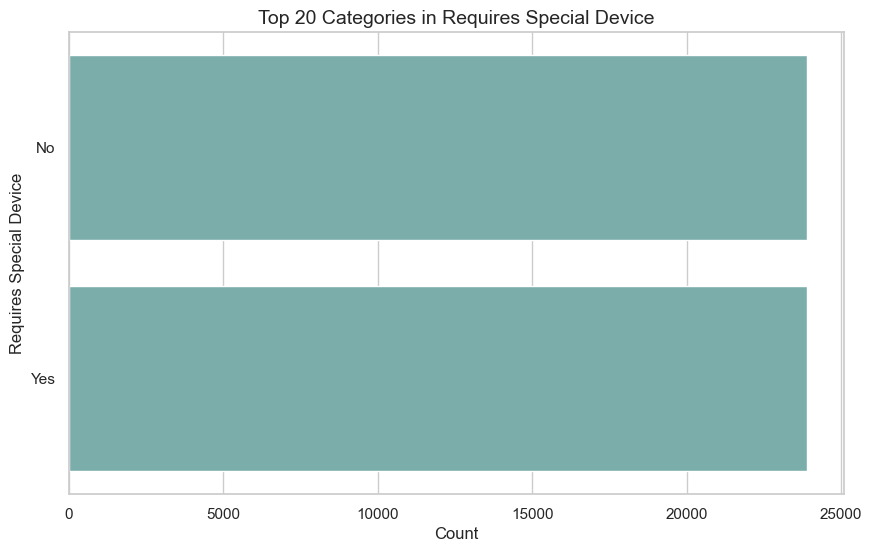

Top categories for Requires Special Device:
Requires Special Device
No     23887
Yes    23887
Name: count, dtype: int64



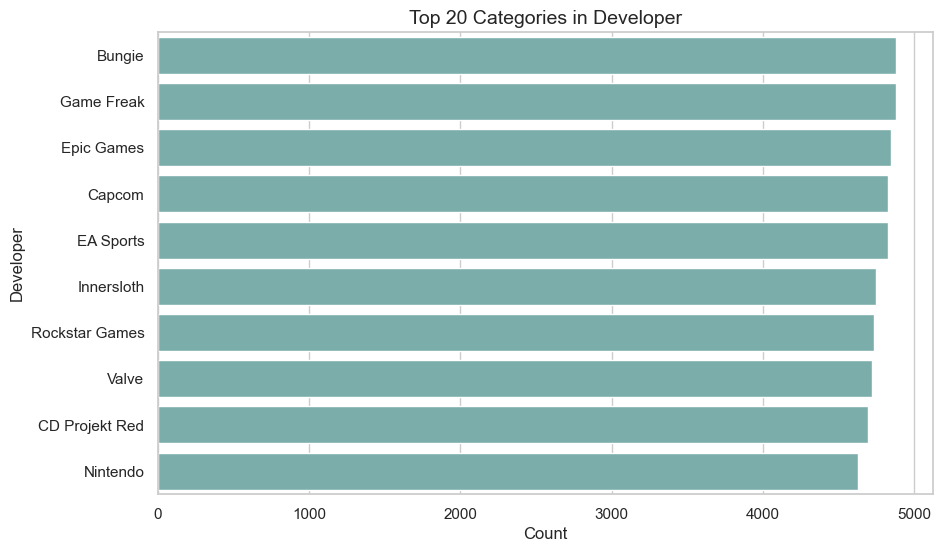

Top categories for Developer:
Developer
Bungie            4877
Game Freak        4876
Epic Games        4845
Capcom            4826
EA Sports         4826
Innersloth        4747
Rockstar Games    4736
Valve             4717
CD Projekt Red    4696
Nintendo          4628
Name: count, dtype: int64



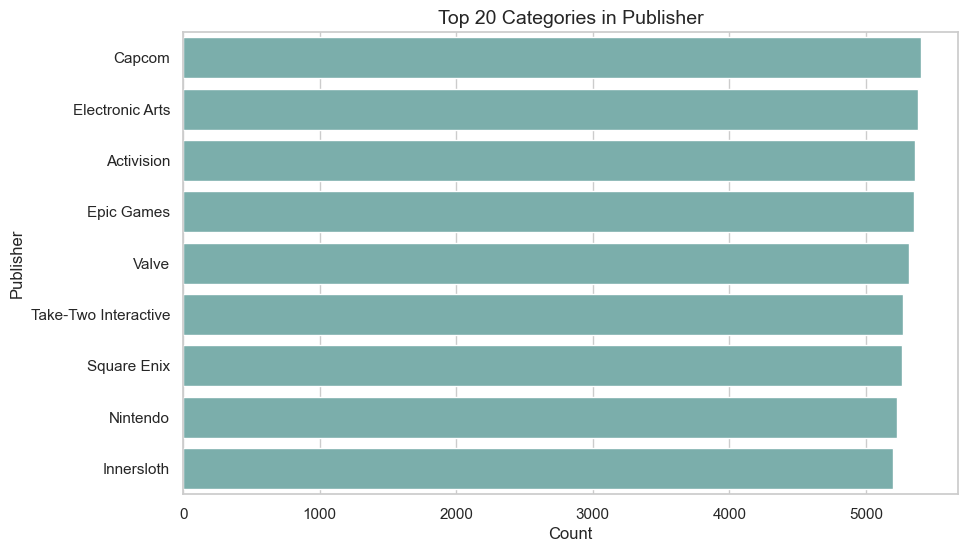

Top categories for Publisher:
Publisher
Capcom                  5406
Electronic Arts         5382
Activision              5360
Epic Games              5353
Valve                   5316
Take-Two Interactive    5269
Square Enix             5262
Nintendo                5226
Innersloth              5200
Name: count, dtype: int64



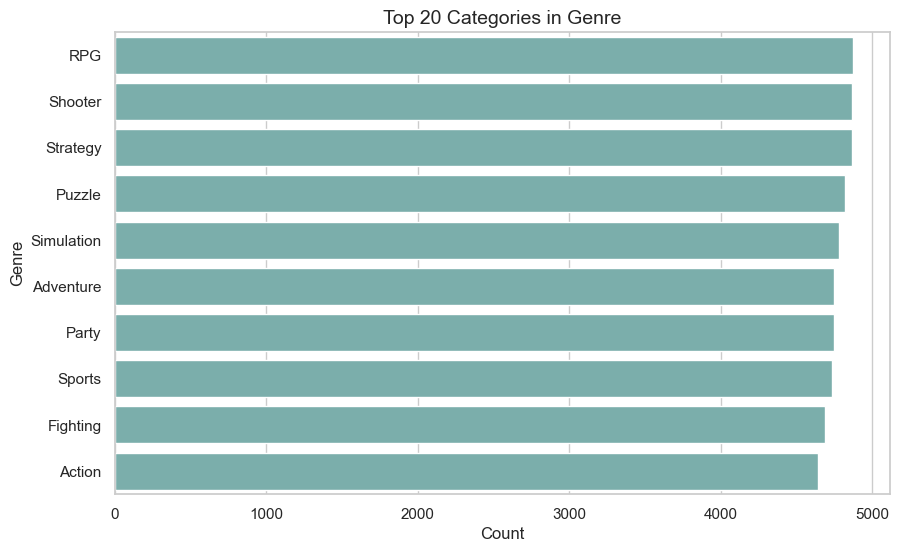

Top categories for Genre:
Genre
RPG           4873
Shooter       4869
Strategy      4867
Puzzle        4822
Simulation    4784
Adventure     4750
Party         4748
Sports        4735
Fighting      4687
Action        4639
Name: count, dtype: int64



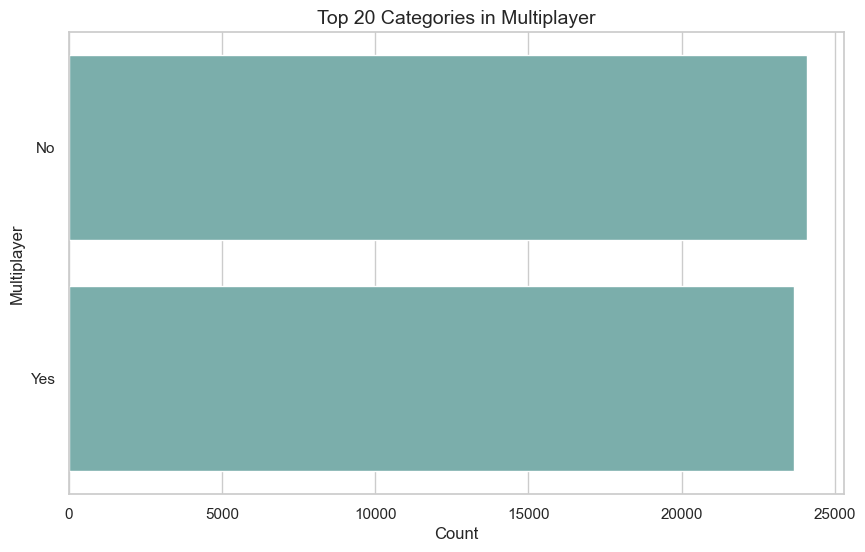

Top categories for Multiplayer:
Multiplayer
No     24090
Yes    23684
Name: count, dtype: int64



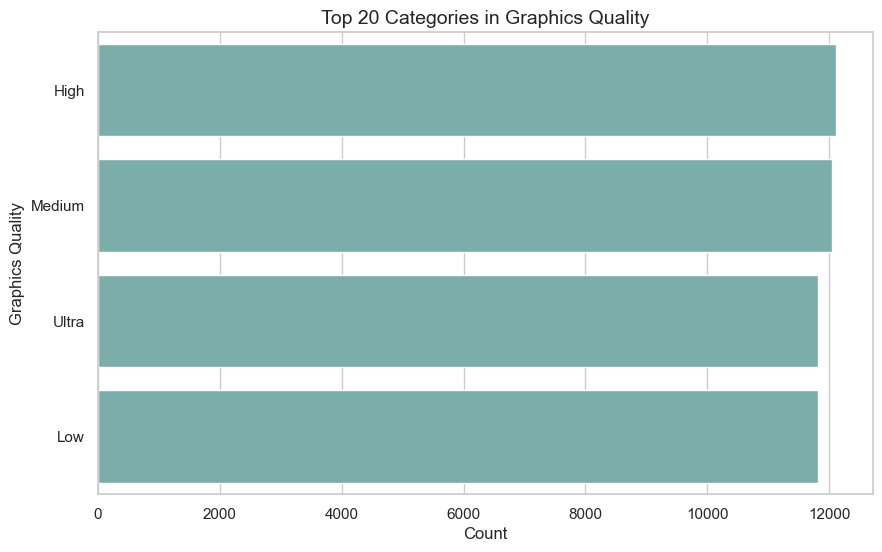

Top categories for Graphics Quality:
Graphics Quality
High      12113
Medium    12040
Ultra     11811
Low       11810
Name: count, dtype: int64



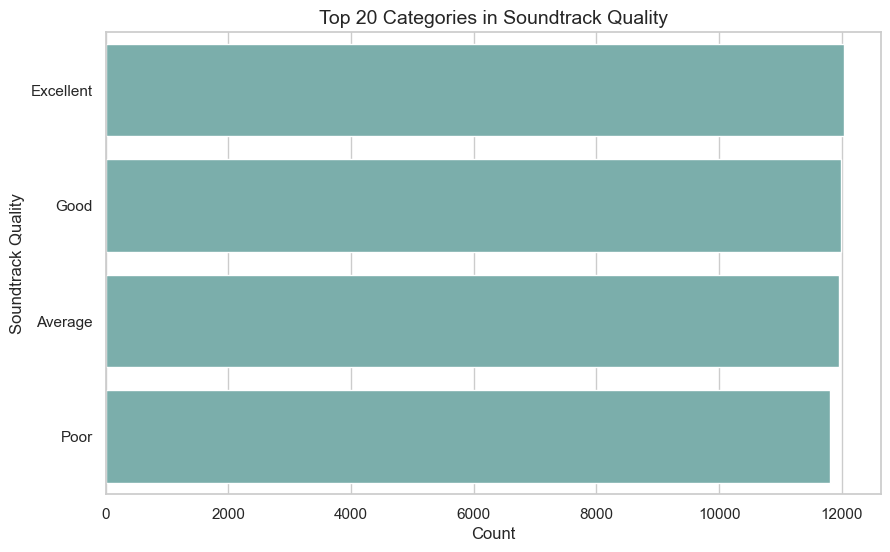

Top categories for Soundtrack Quality:
Soundtrack Quality
Excellent    12036
Good         11985
Average      11952
Poor         11801
Name: count, dtype: int64



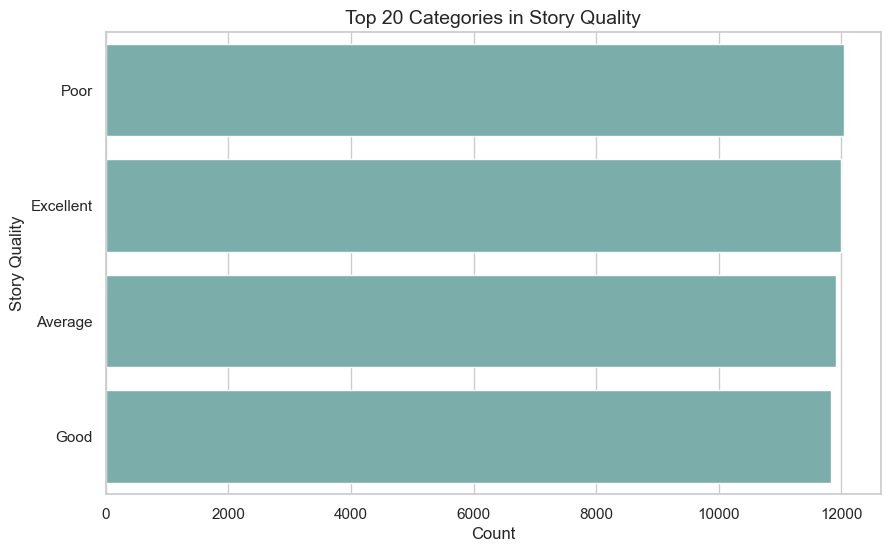

Top categories for Story Quality:
Story Quality
Poor         12041
Excellent    11987
Average      11919
Good         11827
Name: count, dtype: int64



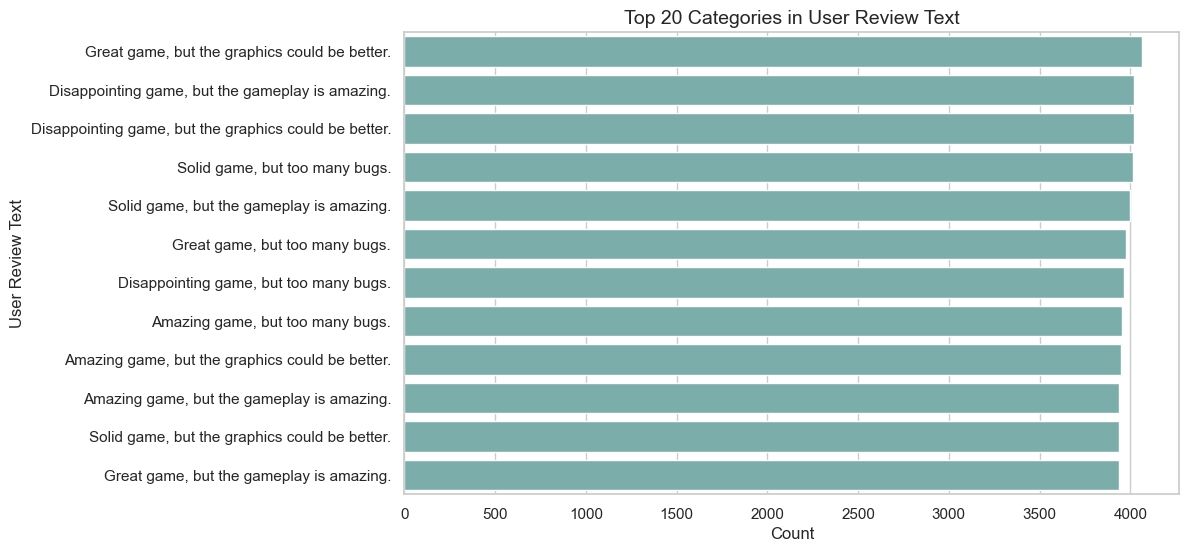

Top categories for User Review Text:
User Review Text
Great game, but the graphics could be better.            4067
Disappointing game, but the gameplay is amazing.         4020
Disappointing game, but the graphics could be better.    4018
Solid game, but too many bugs.                           4017
Solid game, but the gameplay is amazing.                 3996
Great game, but too many bugs.                           3977
Disappointing game, but too many bugs.                   3963
Amazing game, but too many bugs.                         3953
Amazing game, but the graphics could be better.          3948
Amazing game, but the gameplay is amazing.               3939
Name: count, dtype: int64



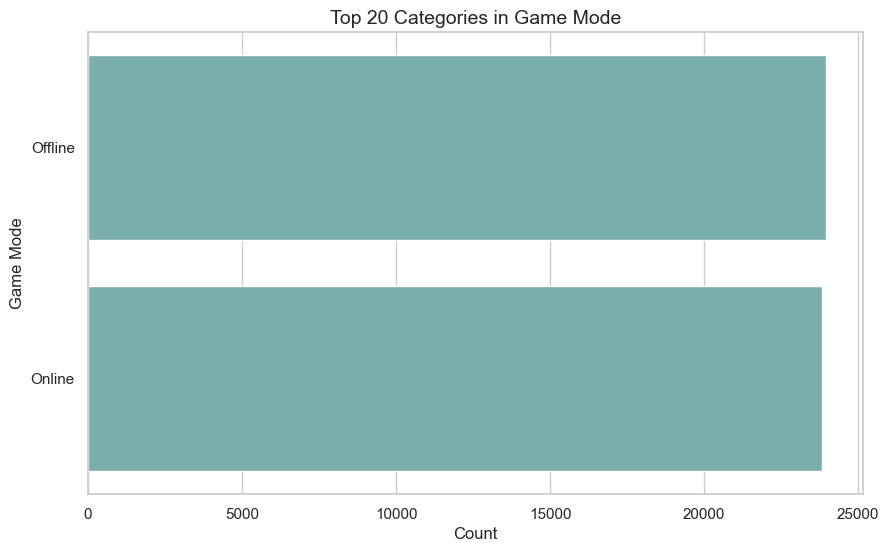

Top categories for Game Mode:
Game Mode
Offline    23957
Online     23817
Name: count, dtype: int64



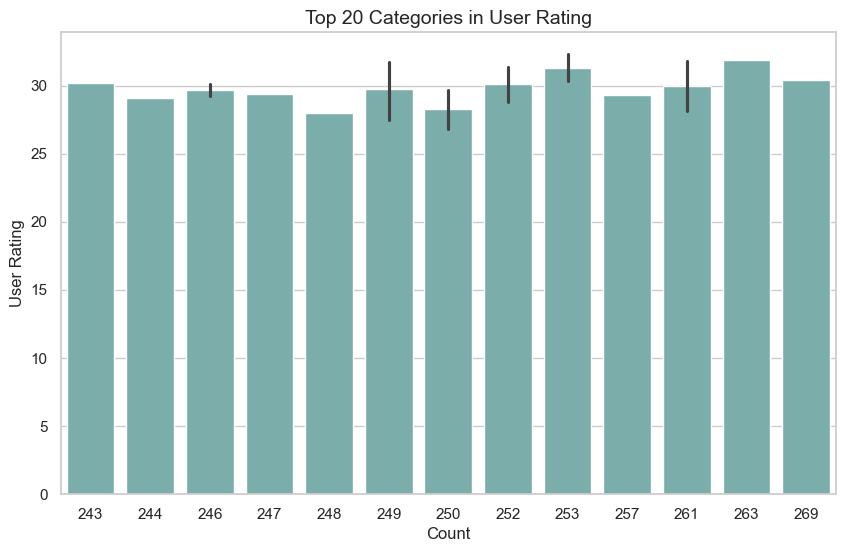

Top categories for User Rating:
User Rating
30.4    269
31.9    263
31.8    261
28.1    261
29.3    257
32.3    253
30.3    253
28.8    252
31.4    252
29.7    250
Name: count, dtype: int64



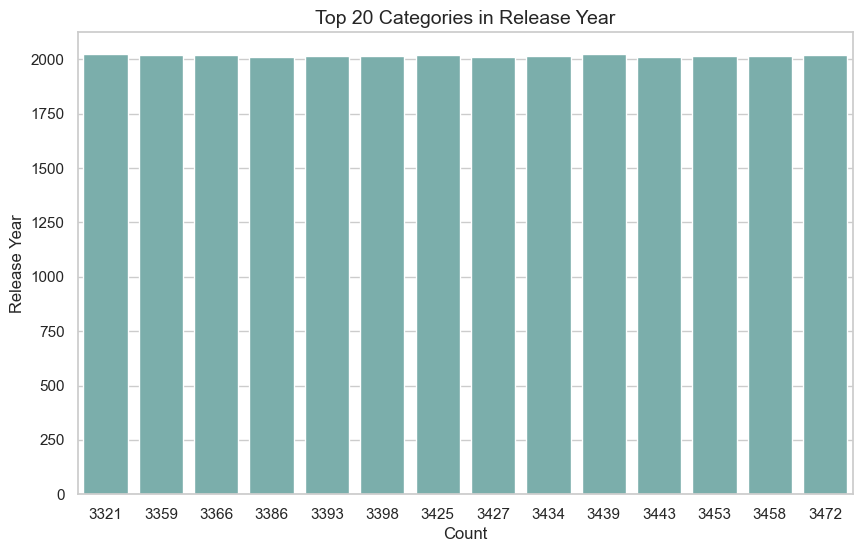

Top categories for Release Year:
Release Year
2020    3472
2014    3458
2015    3453
2010    3443
2022    3439
2013    3434
2011    3427
2019    3425
2016    3398
2017    3393
Name: count, dtype: int64



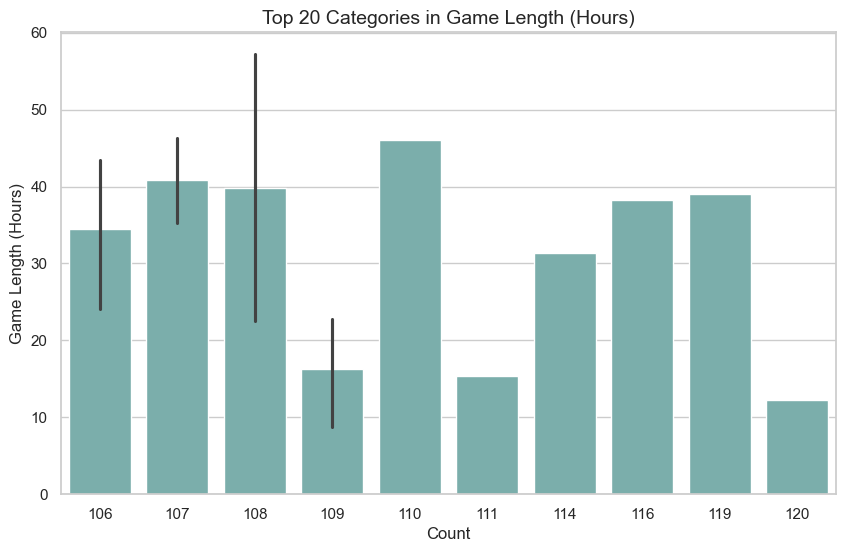

Top categories for Game Length (Hours):
Game Length (Hours)
12.3    120
39.0    119
38.3    116
31.3    114
15.4    111
46.0    110
17.3    109
8.7     109
22.8    109
57.2    108
Name: count, dtype: int64



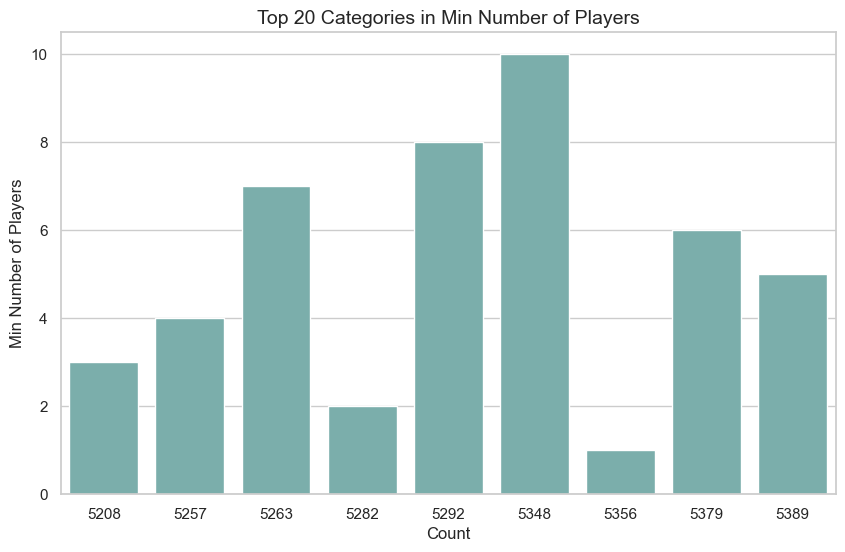

Top categories for Min Number of Players:
Min Number of Players
5     5389
6     5379
1     5356
10    5348
8     5292
2     5282
7     5263
4     5257
3     5208
Name: count, dtype: int64



In [9]:
# Plot bar charts for categorical variables (top categories)
for col in categorical_cols:
    plot_bar_counts(df, col, top_n=20)
    counts = df[col].astype("object").value_counts(dropna=False)
    print(f"Top categories for {col}:\n{counts.head(10)}\n")


### Notes on Distributions

- Numerical variables: note shape (normal vs. skewed), heavy tails, and potential transformations (log, box-cox) if appropriate.
- Categorical variables: identify dominant categories, class imbalance risks, and rare levels that may need grouping.


## 4️⃣ Target Variable Analysis

Specify your target variable name below if known. The notebook will adapt based on whether it is numerical or categorical.


In [10]:
# Set your target variable here (string); set to None if unknown yet
target_col = None  # e.g., "User Rating" or "label"

if target_col is not None and target_col in df.columns:
    if pd.api.types.is_numeric_dtype(df[target_col]):
        print(f"Target '{target_col}' detected as numerical.")
        plot_histogram(df, target_col)
        display(df[target_col].describe())
    else:
        print(f"Target '{target_col}' detected as categorical.")
        counts = df[target_col].astype("object").value_counts(dropna=False)
        ax = sns.barplot(x=counts.values, y=counts.index, color="#E45756")
        ax.set_title(f"Value Counts of {target_col}")
        ax.set_xlabel("Count")
        ax.set_ylabel(target_col)
        plt.show()
        display(counts)
else:
    print("No target column specified or not found in dataframe. Set `target_col` to proceed.")


No target column specified or not found in dataframe. Set `target_col` to proceed.


## 5️⃣ Handle Missing Values

We discuss strategies and implement a reasonable default: for numerical columns, impute with median; for categorical columns, impute with mode. We record the actions and show the resulting shape.


In [11]:
# Create a working copy for cleaning steps
df_working = df.copy()

cleaning_actions = {
    "missing": {},
    "zeros": {},
    "outliers": {},
    "variance": {}
}

# Strategy: median for numeric, mode for categorical
num_cols = get_numeric_columns(df_working)
cat_cols = get_categorical_columns(df_working)

for col in num_cols:
    if df_working[col].isna().any():
        median_val = df_working[col].median()
        df_working[col] = df_working[col].fillna(median_val)
        cleaning_actions["missing"][col] = f"filled with median ({median_val})"

for col in cat_cols:
    if df_working[col].isna().any():
        mode_val = df_working[col].mode(dropna=True)
        mode_val = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
        df_working[col] = df_working[col].fillna(mode_val)
        cleaning_actions["missing"][col] = f"filled with mode ('{mode_val}')"

print("After missing-value imputation:", df_working.shape)
df_working.isna().sum().sort_values(ascending=False).head()


After missing-value imputation: (47774, 18)


Game Title            0
User Rating           0
Age Group Targeted    0
Price                 0
Platform              0
dtype: int64

## 6️⃣ Handle Zeros

We determine whether zeros represent valid values or placeholders. For demonstration, we apply a heuristic: for numeric columns with many zeros and positive distributions, treat zeros as missing and impute with median of non-zero values. Adjust thresholds as needed.


In [12]:
# Heuristic zero handling
zero_summary = compute_zero_summary(df_working)

zero_threshold_pct = 40.0  # consider "high" zero columns
candidate_zero_cols = [
    c for c in get_numeric_columns(df_working)
    if c in zero_summary.index and zero_summary.loc[c, "zero_pct"] >= zero_threshold_pct
]

for col in candidate_zero_cols:
    series = df_working[col]
    # Only consider columns whose non-zero values are mostly positive
    non_zero = series[series != 0]
    if len(non_zero) == 0:
        continue
    if (non_zero >= 0).mean() > 0.95:  # largely non-negative domain
        median_non_zero = non_zero.median()
        df_working[col] = series.replace(0, np.nan).fillna(median_non_zero)
        cleaning_actions["zeros"][col] = (
            f"zeros treated as missing; imputed with non-zero median ({median_non_zero})"
        )

print("Zero handling candidates:", candidate_zero_cols)
zero_summary_after = compute_zero_summary(df_working)
zero_summary_after.head(10)


Zero handling candidates: []


,zero_count,zero_pct
Game Title,0,0.0
User Rating,0,0.0
Age Group Targeted,0,0.0
Price,0,0.0
Platform,0,0.0
Requires Special Device,0,0.0
Developer,0,0.0
Publisher,0,0.0
Release Year,0,0.0
Genre,0,0.0


## 7️⃣ Outlier Detection and Handling

We detect outliers using both IQR and Z-score methods, visualize with boxplots, and apply a conservative capping strategy (winsorization) for numeric columns.


In [13]:
# Detect outliers via IQR and Z-score; then cap at IQR bounds
numeric_cols = get_numeric_columns(df_working)

outlier_report = []
for col in numeric_cols:
    series = df_working[col].astype(float)
    # IQR bounds
    lower_iqr, upper_iqr = iqr_outlier_bounds(series)
    iqr_mask = (series < lower_iqr) | (series > upper_iqr)
    iqr_count = int(iqr_mask.sum())

    # Z-score outliers (>|3|)
    z = zscore(series)
    z_mask = z.abs() > 3
    z_count = int(z_mask.sum())

    outlier_report.append({
        "column": col,
        "iqr_lower": lower_iqr,
        "iqr_upper": upper_iqr,
        "iqr_count": iqr_count,
        "z_count": z_count
    })

outlier_df = pd.DataFrame(outlier_report).sort_values(["iqr_count", "z_count"], ascending=False)
outlier_df.head(10)


,column,iqr_lower,iqr_upper,iqr_count,z_count
0,User Rating,8.10000,51.30000,0,0
1,Price,0.03875,79.90875,0,0
2,Release Year,2002.50000,2030.50000,0,0
3,Game Length (Hours),-22.45000,87.55000,0,0
4,Min Number of Players,-3.00000,13.00000,0,0


In [14]:
# Visualize top outlier columns with boxplots (up to 6)
cols_to_plot = outlier_df[outlier_df["iqr_count"] > 0]["column"].head(6).tolist()
for col in cols_to_plot:
    ax = sns.boxplot(x=df_working[col], color="#B279A2")
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
    plt.show()

# Apply winsorization: cap values outside IQR bounds
for _, row in outlier_df.iterrows():
    col = row["column"]
    lower = row["iqr_lower"]
    upper = row["iqr_upper"]
    before_min, before_max = df_working[col].min(), df_working[col].max()
    df_working[col] = df_working[col].clip(lower=lower, upper=upper)
    after_min, after_max = df_working[col].min(), df_working[col].max()
    if before_min != after_min or before_max != after_max:
        cleaning_actions["outliers"][col] = f"winsorized to [{lower:.3g}, {upper:.3g}]"

print("Applied winsorization to numeric columns where needed.")


Applied winsorization to numeric columns where needed.


## 8️⃣ Variance Analysis

We compute variance for numerical variables, flag near-constant features, and optionally remove low-variance columns.


In [15]:
# Variance computation and removal of very low-variance features
numeric_cols = get_numeric_columns(df_working)
var_series = df_working[numeric_cols].var(numeric_only=True)

# Threshold for low variance (tunable). Here we use a very small threshold.
variance_threshold = 1e-6
low_variance_cols = var_series[var_series <= variance_threshold].index.tolist()

print("Low-variance columns:", low_variance_cols)

# Optionally drop them
for col in low_variance_cols:
    df_working = df_working.drop(columns=[col])
    cleaning_actions["variance"][col] = f"dropped (variance={var_series[col]:.3g})"

print("After variance-based drops:", df_working.shape)
var_series.sort_values().head(10)


Low-variance columns: []
After variance-based drops: (47774, 18)


Min Number of Players      7.670247
Release Year              16.218956
User Rating               57.004483
Price                    132.718281
Game Length (Hours)      251.936521
dtype: float64

## ✅ Finalize Cleaned Dataset and Summary

We finalize `df_cleaned`, print a concise summary of actions taken, and provide dataset info for downstream tasks.


In [16]:
# Finalize cleaned dataset

df_cleaned = df_working.copy()

print("df_cleaned shape:", df_cleaned.shape)
print("Columns:", list(df_cleaned.columns))
print("\nDtypes:\n", df_cleaned.dtypes)
print("\nMissing values (counts):\n", df_cleaned.isna().sum().sort_values(ascending=False).head(20))

# Summarize cleaning actions
print("\n=== Cleaning Actions Summary ===")
for section, actions in cleaning_actions.items():
    print(f"\n[{section.upper()}]")
    if not actions:
        print("(no changes)")
    else:
        for col, desc in actions.items():
            print(f"- {col}: {desc}")


df_cleaned shape: (47774, 18)
Columns: ['Game Title', 'User Rating', 'Age Group Targeted', 'Price', 'Platform', 'Requires Special Device', 'Developer', 'Publisher', 'Release Year', 'Genre', 'Multiplayer', 'Game Length (Hours)', 'Graphics Quality', 'Soundtrack Quality', 'Story Quality', 'User Review Text', 'Game Mode', 'Min Number of Players']

Dtypes:
 Game Title                  object
User Rating                float64
Age Group Targeted          object
Price                      float64
Platform                    object
Requires Special Device     object
Developer                   object
Publisher                   object
Release Year                 int64
Genre                       object
Multiplayer                 object
Game Length (Hours)        float64
Graphics Quality            object
Soundtrack Quality          object
Story Quality               object
User Review Text            object
Game Mode                   object
Min Number of Players        int64
dtype: object

